In [4]:
# ============================================================
# IMPORTATION DES LIBRAIRIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_theme(style="whitegrid")

In [5]:
# ============================================================
# CHARGEMENT DES DONNÉES
# ============================================================

df = pd.read_excel("US_Superstore_data.xls")   

print(df.shape)
print(df.head())

(9994, 21)
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   South

In [6]:
# ============================================================
# NETTOYAGE ET PRETRAITEMENT
# ============================================================

print(df.info())

print("\nValeurs manquantes")
print(df.isnull().sum())

# Conversion des dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Suppression éventuelle des doublons
df = df.drop_duplicates()

print("\nDimensions après nettoyage :", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

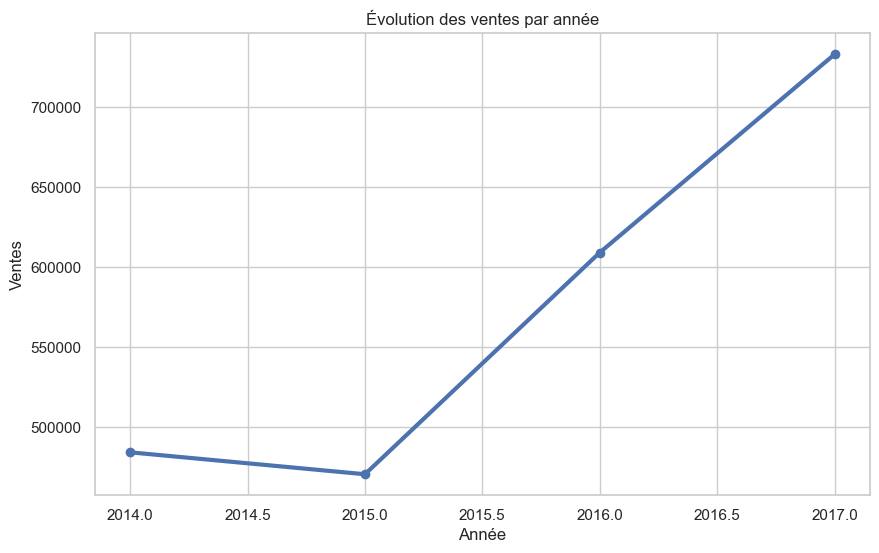

In [7]:
# ============================================================
# VENTES PAR ANNEE
# ============================================================

sales_by_year = (
    df.groupby(df["Order Date"].dt.year)["Sales"]
      .sum()
)

plt.figure(figsize=(10,6))

plt.plot(
    sales_by_year.index,
    sales_by_year.values,
    marker="o",
    linewidth=3
)

plt.title("Évolution des ventes par année")
plt.xlabel("Année")
plt.ylabel("Ventes")
plt.grid(True)

plt.show()

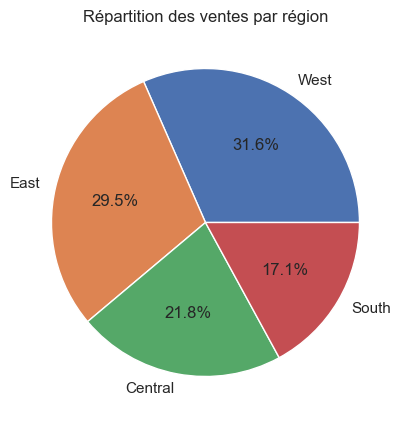

In [8]:
# ============================================================
# REPARTITION DES VENTES PAR REGION
# ============================================================

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

plt.pie(
    region_sales,
    labels=region_sales.index,
    autopct='%1.1f%%'
)

plt.title("Répartition des ventes par région")

plt.show()

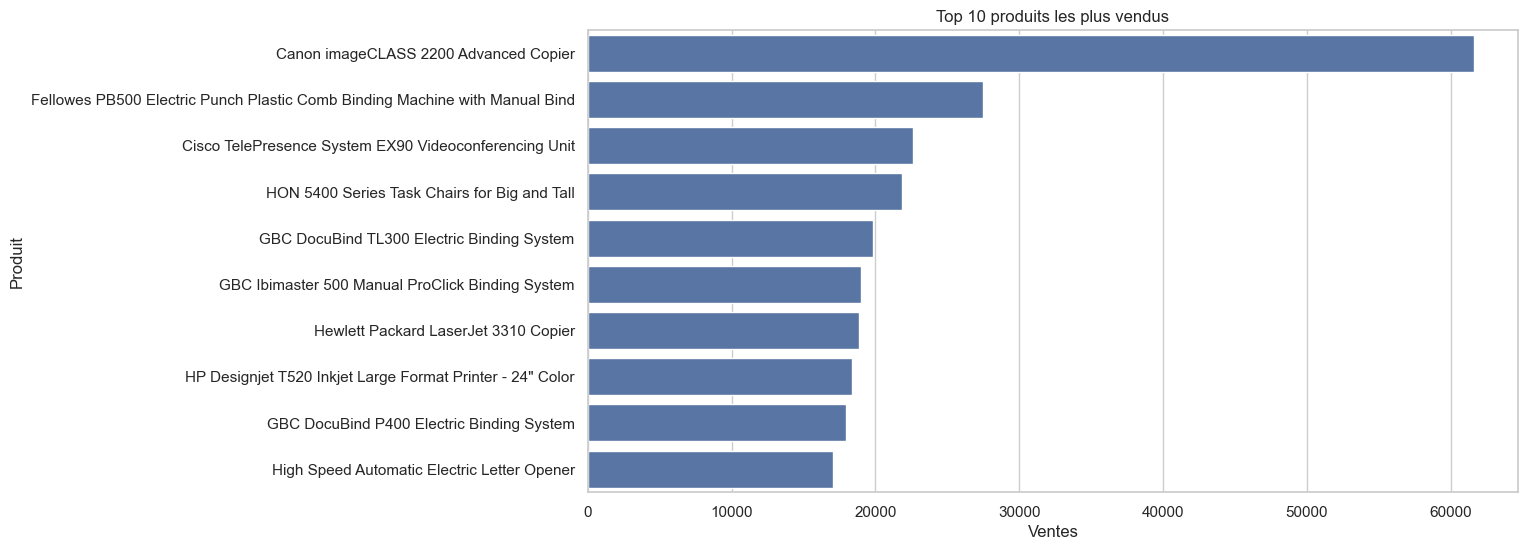

In [9]:
# ============================================================
# TOP 10 PRODUITS
# ============================================================

top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 produits les plus vendus")
plt.xlabel("Ventes")
plt.ylabel("Produit")

plt.show()

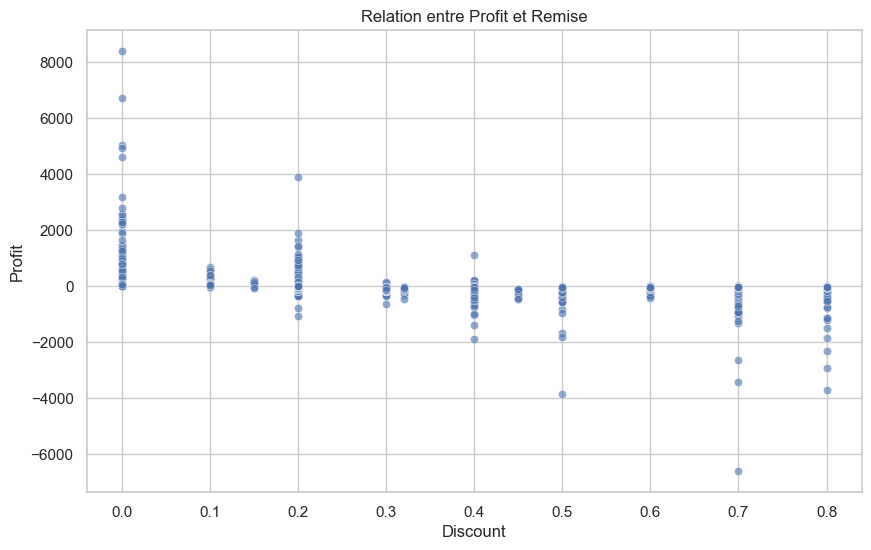

In [10]:
# ============================================================
# PROFIT VS DISCOUNT
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.6
)

plt.title("Relation entre Profit et Remise")

plt.show()